# Chapter 41 — Exponents and Powers

> **Prerequisites:** ch022 (Natural Numbers), ch023 (Integers), ch026 (Real Numbers), ch031 (Modular Arithmetic)  
> **You will learn:**
> - What exponentiation is and why it differs fundamentally from multiplication
> - Integer, rational, and real exponents — and what each generalizes
> - How computers compute powers efficiently (fast exponentiation)
> - The mathematical rules (laws of exponents) and where they break down
> - Connections to growth, scientific notation, and algorithm complexity
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Exponentiation answers the question: *what happens when you apply multiplication the way multiplication applies addition?*

- Addition: combine equal groups of 1 → `n + n + n = 3n` (multiplication)
- Multiplication: combine equal groups of n → `n × n × n = n³` (exponentiation)

The expression `b^n` (read: *b to the power n*) means: multiply `b` by itself `n` times.

```
2^1 = 2
2^2 = 2 × 2 = 4
2^3 = 2 × 2 × 2 = 8
2^10 = 1024
2^32 = 4,294,967,296
```

The growth rate here is qualitatively different from addition or multiplication. Each increment of the exponent *multiplies* the result, not adds to it.

**Terminology:**
- `b` is the **base**
- `n` is the **exponent** (or **power**)
- The result is a **power of b**

**Common misconception:** `b^n` is *not* `b × n`. Students write `2^3 = 6` (confusing with `2 × 3`). The exponent tells you how many times to use `b` as a factor, not how many times to add it.

**Scope of this chapter:** We focus on the structure and laws of exponentiation — integer, then rational, then real exponents. The *behavior* of exponential functions (growth, decay, rates) is covered in ch042.

---

## 2. Intuition & Mental Models

**Geometric analogy:** Think of `b^n` as measuring *n*-dimensional volume with side length `b`.
- `b^1` = a line segment of length b
- `b^2` = a square with side b (area)
- `b^3` = a cube with side b (volume)
- `b^4` and beyond = a hypercube (you can't picture it, but the math still works)

This is why `b^2` is called "b squared" and `b^3` is "b cubed" — literal geometric origins.

**Computational analogy:** Think of `b^n` as a *chain of multiplications*. A computer implementing `pow(b, n)` naively does exactly `n-1` multiplications. But — and this is important — there's a smarter way. We'll implement it in Section 5.

**Fractional exponents:** `b^(1/2)` = the number that, when squared, gives `b`. That's the square root. So `b^(1/n)` = the n-th root of b. Exponentiation and root-taking are inverses *(this will become precise in ch043 — Logarithms Intuition)*.

**Negative exponents:** `b^(-n) = 1 / b^n`. Think of it as "going in reverse" on the multiplication chain. `2^3 = 8`, so `2^(-3) = 1/8`. *(Introduced in the context of rational numbers in ch024.)*

**Zero exponent:** `b^0 = 1` for any `b ≠ 0`. This follows from the division rule: `b^n / b^n = b^(n-n) = b^0`, and any number divided by itself is 1.

---

## 3. Visualization

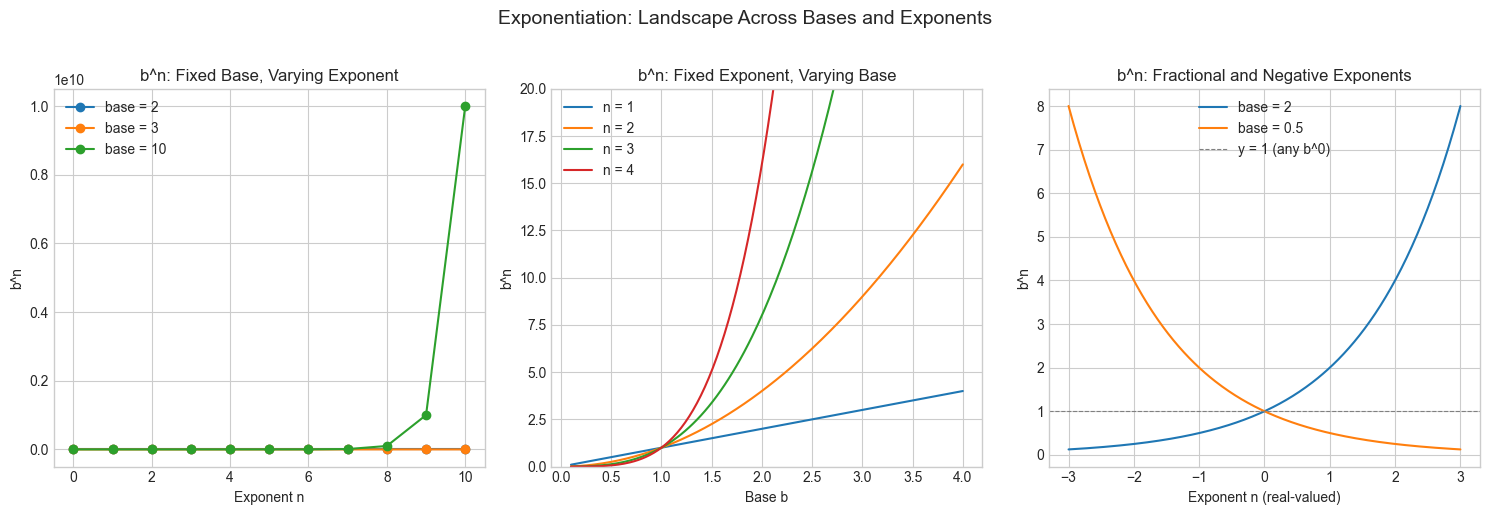

In [1]:
# --- Visualization: Exponent landscape — how b^n behaves across bases and exponents ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: b^n for fixed base b, varying exponent n ---
ax = axes[0]
exponents = np.arange(0, 11)
for base in [2, 3, 10]:
    values = base ** exponents
    ax.plot(exponents, values, marker='o', label=f'base = {base}')
ax.set_title('b^n: Fixed Base, Varying Exponent')
ax.set_xlabel('Exponent n')
ax.set_ylabel('b^n')
ax.legend()

# --- Panel 2: b^n for fixed exponent n, varying base b ---
ax = axes[1]
bases = np.linspace(0.1, 4, 200)
for exp in [1, 2, 3, 4]:
    ax.plot(bases, bases ** exp, label=f'n = {exp}')
ax.set_title('b^n: Fixed Exponent, Varying Base')
ax.set_xlabel('Base b')
ax.set_ylabel('b^n')
ax.legend()
ax.set_ylim(0, 20)

# --- Panel 3: Negative and fractional exponents ---
ax = axes[2]
exps = np.linspace(-3, 3, 300)
for base in [2, 0.5]:
    ax.plot(exps, base ** exps, label=f'base = {base}')
ax.axhline(1, color='gray', linestyle='--', linewidth=0.8, label='y = 1 (any b^0)')
ax.set_title('b^n: Fractional and Negative Exponents')
ax.set_xlabel('Exponent n (real-valued)')
ax.set_ylabel('b^n')
ax.legend()

plt.suptitle('Exponentiation: Landscape Across Bases and Exponents', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

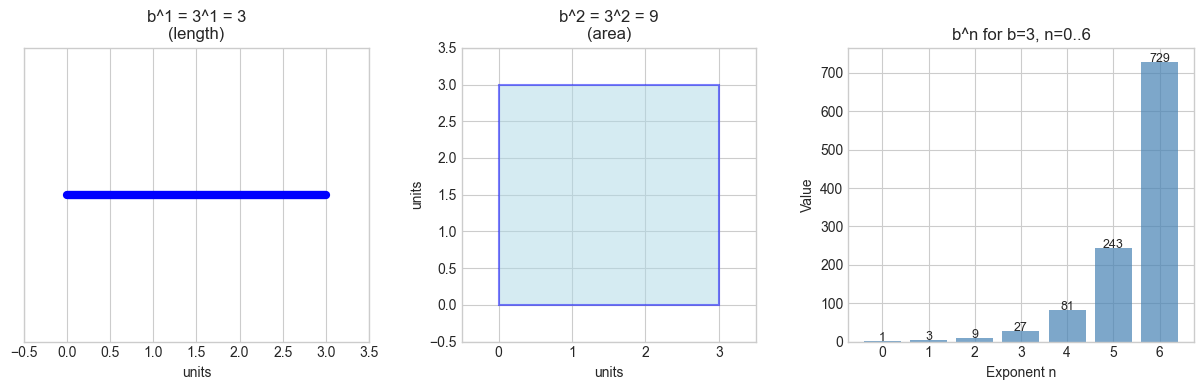

In [2]:
# --- Visualization: The geometric interpretation (squares and cubes) ---
import matplotlib.patches as patches

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

BASE = 3  # b = 3

# b^1: line
ax = axes[0]
ax.plot([0, BASE], [0.5, 0.5], 'b-', linewidth=6)
ax.set_xlim(-0.5, BASE + 0.5)
ax.set_ylim(0, 1)
ax.set_title(f'b^1 = {BASE}^1 = {BASE}\n(length)')
ax.set_xlabel('units')
ax.set_yticks([])

# b^2: square
ax = axes[1]
square = patches.Rectangle((0, 0), BASE, BASE, linewidth=1.5,
                             edgecolor='blue', facecolor='lightblue', alpha=0.5)
ax.add_patch(square)
ax.set_xlim(-0.5, BASE + 0.5)
ax.set_ylim(-0.5, BASE + 0.5)
ax.set_aspect('equal')
ax.set_title(f'b^2 = {BASE}^2 = {BASE**2}\n(area)')
ax.set_xlabel('units')
ax.set_ylabel('units')

# b^n: value plot showing geometric growth
ax = axes[2]
ns = np.arange(0, 7)
vals = BASE ** ns
ax.bar(ns, vals, color='steelblue', alpha=0.7)
for i, v in zip(ns, vals):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
ax.set_title(f'b^n for b={BASE}, n=0..6')
ax.set_xlabel('Exponent n')
ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Definition for integer exponents

For `b ∈ ℝ`, `n ∈ ℕ` (positive integer):

```
b^n = b × b × b × ... × b    (n times)
b^0 = 1                        (by convention, b ≠ 0)
b^(-n) = 1 / b^n               (n > 0, b ≠ 0)
```

### Laws of exponents

These follow directly from the definition. Let `b, c > 0` and `m, n ∈ ℝ`:

```
1.  b^m × b^n = b^(m+n)        # product rule: count the factors
2.  b^m / b^n = b^(m-n)        # quotient rule: cancel common factors
3.  (b^m)^n  = b^(m×n)         # power of a power: flatten the nesting
4.  (b×c)^n  = b^n × c^n       # distribute over multiplication
5.  (b/c)^n  = b^n / c^n       # distribute over division
```

### Extension to rational exponents

For `p/q` in lowest terms, `q > 0`, `b > 0`:

```
b^(p/q) = (b^(1/q))^p = (q-th root of b)^p
```

Example: `8^(2/3) = (cube_root(8))^2 = 2^2 = 4`

### Extension to real exponents

For irrational exponents (like `2^π`), the definition requires limits *(covered in ch201 — Limits Intuition)*:

```
b^x = lim_{r→x, r rational} b^r
```

In practice: compute via `exp(x × ln(b))` — the natural logarithm and exponential function *(ch043, ch044)*.

In [3]:
# --- Verify laws of exponents numerically ---
import numpy as np

b, c = 3.0, 2.0
m, n = 4.0, 3.0

print("Laws of Exponents — Numerical Verification")
print("-" * 50)

# Law 1: b^m × b^n = b^(m+n)
lhs = b**m * b**n
rhs = b**(m + n)
print(f"1. b^m × b^n = b^(m+n):  {lhs:.4f} == {rhs:.4f}  {'✓' if np.isclose(lhs, rhs) else '✗'}")

# Law 2: b^m / b^n = b^(m-n)
lhs = b**m / b**n
rhs = b**(m - n)
print(f"2. b^m / b^n = b^(m-n):  {lhs:.4f} == {rhs:.4f}  {'✓' if np.isclose(lhs, rhs) else '✗'}")

# Law 3: (b^m)^n = b^(m×n)
lhs = (b**m)**n
rhs = b**(m * n)
print(f"3. (b^m)^n  = b^(m×n):   {lhs:.4f} == {rhs:.4f}  {'✓' if np.isclose(lhs, rhs) else '✗'}")

# Law 4: (b×c)^n = b^n × c^n
lhs = (b * c)**n
rhs = b**n * c**n
print(f"4. (b×c)^n = b^n × c^n: {lhs:.4f} == {rhs:.4f}  {'✓' if np.isclose(lhs, rhs) else '✗'}")

# Rational exponent: 8^(2/3)
val = 8 ** (2/3)
expected = 4.0
print(f"\nRational: 8^(2/3) = {val:.6f}  (expected {expected})  {'✓' if np.isclose(val, expected) else '✗'}")

# Real exponent: 2^π via exp(π × ln(2))
val_direct = 2 ** np.pi
val_via_exp = np.exp(np.pi * np.log(2))
print(f"Real: 2^π = {val_direct:.8f}  via exp(π×ln2) = {val_via_exp:.8f}  {'✓' if np.isclose(val_direct, val_via_exp) else '✗'}")

Laws of Exponents — Numerical Verification
--------------------------------------------------
1. b^m × b^n = b^(m+n):  2187.0000 == 2187.0000  ✓
2. b^m / b^n = b^(m-n):  3.0000 == 3.0000  ✓
3. (b^m)^n  = b^(m×n):   531441.0000 == 531441.0000  ✓
4. (b×c)^n = b^n × c^n: 216.0000 == 216.0000  ✓

Rational: 8^(2/3) = 4.000000  (expected 4.0)  ✓
Real: 2^π = 8.82497783  via exp(π×ln2) = 8.82497783  ✓


---

## 5. Python Implementation

### Naive vs fast exponentiation

Python's `**` operator and `pow()` built-in use fast exponentiation internally. Let's implement both to understand the difference.

In [4]:
# --- Implementation: Naive integer exponentiation ---

def power_naive(base, exp):
    """
    Compute base^exp using repeated multiplication.
    Requires exactly (exp - 1) multiplications.

    Args:
        base: numeric base
        exp: non-negative integer exponent

    Returns:
        base raised to exp
    """
    if exp == 0:
        return 1
    result = 1
    for _ in range(exp):
        result *= base  # multiply exp times
    return result


# --- Implementation: Fast exponentiation (exponentiation by squaring) ---

def power_fast(base, exp):
    """
    Compute base^exp using exponentiation by squaring.
    Requires O(log exp) multiplications instead of O(exp).

    Key insight: 
        if exp is even:  base^exp = (base^2)^(exp/2)
        if exp is odd:   base^exp = base × base^(exp-1)

    Args:
        base: numeric base
        exp: non-negative integer exponent

    Returns:
        base raised to exp
    """
    if exp == 0:
        return 1
    if exp % 2 == 0:
        # Even: square the base, halve the exponent
        return power_fast(base * base, exp // 2)
    else:
        # Odd: pull out one factor, recurse on even
        return base * power_fast(base, exp - 1)


# Validate both implementations
test_cases = [(2, 10), (3, 7), (5, 0), (7, 1), (2, 32)]
print("base  exp  naive        fast         python")
print("-" * 55)
for b, e in test_cases:
    naive = power_naive(b, e)
    fast  = power_fast(b, e)
    ref   = b ** e
    match = '✓' if naive == fast == ref else '✗'
    print(f"{b:4d}  {e:3d}  {naive:12d}  {fast:12d}  {ref:12d}  {match}")

base  exp  naive        fast         python
-------------------------------------------------------
   2   10          1024          1024          1024  ✓
   3    7          2187          2187          2187  ✓
   5    0             1             1             1  ✓
   7    1             7             7             7  ✓
   2   32    4294967296    4294967296    4294967296  ✓


C:\Users\user\AppData\Local\Temp\ipykernel_23940\1714877022.py:36: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


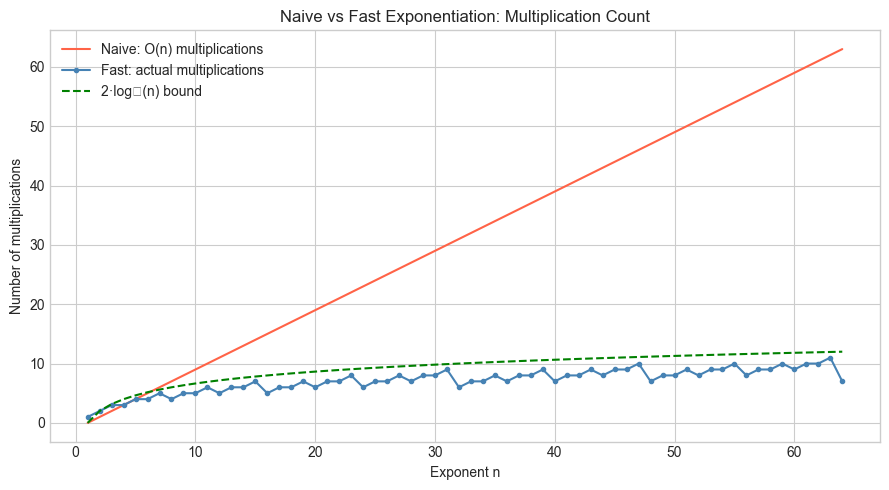


For n=64: naive needs 63 multiplications, fast needs 7


In [5]:
# --- Count multiplications: naive vs fast ---

def power_fast_counting(base, exp, count=None):
    """Same as power_fast but counts the number of multiplications."""
    if count is None:
        count = [0]
    if exp == 0:
        return 1, count[0]
    if exp % 2 == 0:
        count[0] += 1  # the squaring: base * base
        result, _ = power_fast_counting(base * base, exp // 2, count)
        return result, count[0]
    else:
        count[0] += 1  # the outer base * ...
        result, _ = power_fast_counting(base, exp - 1, count)
        return result, count[0]

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

exponents = np.arange(1, 65)
naive_mults = exponents - 1  # always exp-1 multiplications
fast_mults  = [power_fast_counting(2, int(e))[1] for e in exponents]
log2_bound  = np.log2(exponents) * 2  # theoretical O(log n) bound

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(exponents, naive_mults, label='Naive: O(n) multiplications', color='tomato')
ax.plot(exponents, fast_mults,  label='Fast: actual multiplications', color='steelblue', marker='.')
ax.plot(exponents, log2_bound,  label='2·log₂(n) bound', color='green', linestyle='--')
ax.set_title('Naive vs Fast Exponentiation: Multiplication Count')
ax.set_xlabel('Exponent n')
ax.set_ylabel('Number of multiplications')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFor n=64: naive needs {64-1} multiplications, fast needs {power_fast_counting(2, 64)[1]}")

The algorithm's correctness relies on Law 3 from Section 4: `(b^2)^(n/2) = b^(2 × n/2) = b^n`.

This same idea powers **modular exponentiation**, the core of RSA cryptography *(introduced in ch031 — Modular Arithmetic, applied in ch033 — Applications of Modulo)*.

---

## 6. Experiments

In [6]:
# --- Experiment 1: Where do the laws of exponents break down? ---
# Hypothesis: The laws assume b > 0 and real exponents.
# Negative bases with fractional exponents cause problems.
# Try changing: BASE to a negative number, EXP to a fraction

import numpy as np

BASE = -8   # <-- modify this (try -2, -1, 0)
EXP  = 1/3  # <-- modify this (try 2, -1, 0.5)

# Python's float arithmetic
try:
    result_float = BASE ** EXP
    print(f"Python float: ({BASE})^({EXP}) = {result_float}")
except Exception as e:
    print(f"Python float error: {e}")

# NumPy's complex-aware version
result_complex = complex(BASE) ** EXP
print(f"Complex result: ({BASE})^({EXP}) = {result_complex}")

# The real cube root of -8 should be -2 (since (-2)^3 = -8)
# Python cannot compute it as a float because x^(1/3) via exp(ln(x)/3)
# requires ln of a negative number — which is complex.
print(f"\nVerification: (-2)^3 = {(-2)**3}")
print(f"So the real cube root of -8 is -2, but Python gives: {BASE**EXP}")
print("This is why the laws require b > 0 for real-valued exponentiation.")

Python float: (-8)^(0.3333333333333333) = (1.0000000000000002+1.7320508075688772j)
Complex result: (-8)^(0.3333333333333333) = (1.0000000000000002+1.7320508075688772j)

Verification: (-2)^3 = -8
So the real cube root of -8 is -2, but Python gives: (1.0000000000000002+1.7320508075688772j)
This is why the laws require b > 0 for real-valued exponentiation.


In [7]:
# --- Experiment 2: Power towers (iterated exponentiation) ---
# Hypothesis: a^(b^c) ≠ (a^b)^c in general — exponentiation is NOT associative.
# Try changing: A, B, C to explore when they happen to be equal

A = 2  # <-- modify this
B = 3  # <-- modify this
C = 2  # <-- modify this

# Right-associative: a^(b^c) — how power towers work by convention
right = A ** (B ** C)

# Left-associative: (a^b)^c — equivalent to a^(b×c) by Law 3
left = (A ** B) ** C

print(f"a={A}, b={B}, c={C}")
print(f"Right-associative: a^(b^c) = {A}^({B}^{C}) = {A}^{B**C} = {right}")
print(f"Left-associative: (a^b)^c  = ({A}^{B})^{C} = {A**B}^{C}  = {left}")
print(f"Equal? {right == left}")
print(f"\nNote: Law 3 says (a^b)^c = a^(b×c) = {A}^{B*C} = {A**(B*C)}")
print(f"But a^(b^c) = a^{B**C} = {right}  — very different for large exponents!")

a=2, b=3, c=2
Right-associative: a^(b^c) = 2^(3^2) = 2^9 = 512
Left-associative: (a^b)^c  = (2^3)^2 = 8^2  = 64
Equal? False

Note: Law 3 says (a^b)^c = a^(b×c) = 2^6 = 64
But a^(b^c) = a^9 = 512  — very different for large exponents!


In [8]:
# --- Experiment 3: Modular exponentiation (RSA preview) ---
# Hypothesis: (base^exp) mod m can be computed efficiently WITHOUT
# computing the full (astronomically large) base^exp first.
# This is the core operation in RSA encryption.

BASE = 7
EXP  = 1000    # <-- modify this (try 10_000, 100_000)
MOD  = 13      # <-- modify this (try other primes: 17, 29, 97)

# Python's built-in 3-argument pow is optimized for this
result = pow(BASE, EXP, MOD)  # computes (BASE^EXP) mod MOD efficiently

# Naive: compute the full number first (catastrophically slow for large EXP)
# result_naive = (BASE ** EXP) % MOD  # <-- try this for EXP=1000, then comment out

print(f"({BASE}^{EXP}) mod {MOD} = {result}")
print(f"Using Python's 3-arg pow: O(log {EXP}) ≈ {int(EXP.bit_length())} multiplications")
print(f"The full number {BASE}^{EXP} has ~{int(EXP * len(str(BASE)))} digits — never computed.")

(7^1000) mod 13 = 9
Using Python's 3-arg pow: O(log 1000) ≈ 10 multiplications
The full number 7^1000 has ~1000 digits — never computed.


---

## 7. Exercises

**Easy 1.** Compute `5^6` by hand using the product rule. Verify in Python. Then explain why `(5^3)^2 = 5^6` using Law 3.

**Easy 2.** What is `0^0`? In Python, `0**0` returns `1`. Is this mathematically correct? Write 2–3 sentences explaining the two competing perspectives (combinatorics vs analysis).

**Medium 1.** Implement `power_fast` iteratively (without recursion) using a loop. Verify it produces identical results to the recursive version for all exponents 0–100. *(Hint: use the binary representation of the exponent.)*

**Medium 2.** The function `f(n) = 2^n` grows faster than `g(n) = n^2` for large n. Find the crossover point: the smallest integer `n` where `2^n > n^2`. Then find where `2^n > n^10`.

**Hard.** Prove algebraically that the fast exponentiation algorithm is correct. That is, show that `power_fast(b, n)` returns `b^n` for all `n ≥ 0` by strong induction. State the base case, the inductive hypothesis, and the two cases (even/odd) explicitly.

---

## 8. Mini Project: Integer Factorization and Smooth Numbers

In [ ]:
# --- Mini Project: Smooth Numbers and the Cost of Representing Powers ---
#
# Problem:
#   A number is called "B-smooth" if all its prime factors are ≤ B.
#   Powers of small primes are the smoothest numbers — and they appear
#   constantly in algorithm analysis (2^n in binary search, 2^32 in
#   32-bit integers, etc.).
#
#   Your task: Build a tool that, given a number N, finds its representation
#   as a product of prime powers, and computes how many bits it needs.
#
# Dataset: Generated inline (integer powers of small primes)
# Task: Factor a number into prime powers, count its bit length, and
#       visualize the relationship between prime-power structure and bit length.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# --- Starter code: complete the TODOs ---

def prime_factorization(n):
    """
    Return the prime factorization of n as a dict {prime: exponent}.
    Example: prime_factorization(360) → {2: 3, 3: 2, 5: 1}
    """
    factors = {}
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors[d] = factors.get(d, 0) + 1
            n //= d
        d += 1
    if n > 1:
        factors[n] = factors.get(n, 0) + 1
    return factors

def bit_length(n):
    """Number of bits needed to represent n in binary."""
    return n.bit_length()

# TODO 1: Generate 50 numbers that are powers of 2 and 3
#         (i.e., numbers of the form 2^a * 3^b for a,b in 0..10)
#         Hint: nested loop, collect unique values, sort
numbers = sorted(set(
    2**a * 3**b
    for a in range(12)
    for b in range(8)
))

# TODO 2: For each number, compute its bit length and factorization
bit_lengths = [bit_length(n) for n in numbers]
factorizations = [prime_factorization(n) for n in numbers]

# TODO 3: Plot bit_length vs log2(number)
# What do you expect this relationship to look like?
log2_values = np.log2(numbers)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(log2_values, bit_lengths, alpha=0.6, color='steelblue')
ax.set_title('Bit Length vs log₂(n) for 2ᵃ × 3ᵇ numbers')
ax.set_xlabel('log₂(n)')
ax.set_ylabel('Bit length')

# TODO 4: Show which numbers have the most "prime power" structure
#         Color the scatter by the total sum of exponents (a + b)
total_exponents = [sum(f.values()) for f in factorizations]
sc = axes[1].scatter(np.array(numbers), bit_lengths, 
                     c=total_exponents, cmap='viridis', alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='Total exponent sum (a+b)')
axes[1].set_xscale('log')
axes[1].set_title('Bit Length vs Number (log scale), colored by exponent sum')
axes[1].set_xlabel('n (log scale)')
axes[1].set_ylabel('Bit length')

plt.tight_layout()
plt.show()

# Inspect a few
print("Sample factorizations:")
for n in [1, 8, 12, 72, 576, 1152]:
    f = prime_factorization(n)
    expr = ' × '.join(f'{p}^{e}' for p, e in sorted(f.items()))
    print(f"  {n:6d} = {expr:20s}  ({bit_length(n)} bits)")

---

## 9. Chapter Summary & Connections

- `b^n` is repeated multiplication: qualitatively faster-growing than multiplication is to addition.
- The five laws of exponents are not axioms — they follow from the definition, and they break down outside their stated domain (e.g., negative bases, complex exponents).
- Fast exponentiation (exponentiation by squaring) reduces `O(n)` multiplications to `O(log n)` using the power-of-a-power law. This is not a trick — it's an algorithmic consequence of the math.
- Negative and fractional exponents extend the integer definition coherently: `b^(-n) = 1/b^n`, `b^(1/n)` = nth root.
- For real exponents, the definition requires limits and the natural exponential — a thread picked up in ch043.

**Backward connection:** The prime factorization in the mini project relies on ch028 (Prime Numbers) and ch029 (Factorization). The modular exponentiation experiment builds directly on ch031 (Modular Arithmetic).

**Forward connections:**
- This chapter is the prerequisite for ch042 (Exponential Growth), where `b^n` becomes `b^t` as a continuous function of time.
- The inverse of exponentiation — answering "what exponent gives this value?" — is the logarithm, covered in ch043 (Logarithms Intuition).
- Fast exponentiation reappears in ch033 (Applications of Modulo) in the context of RSA, and in ch151 (Introduction to Matrices) as matrix exponentiation for solving recurrences.

**Going deeper:** *The Art of Computer Programming*, Vol. 2 (Knuth), Section 4.6 — addition chains and optimal exponentiation algorithms.